In [1]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance_old import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions
from glass_dynamics.analysis.residuals_analysis import compute_global_viscosity_residuals

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap
from glass_dynamics.visualization.residuals_plots import plot_viscosity_compound_residuals

from glass_dynamics.models.ridge import CustomRidgeRegression

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "ridge_analysis_full"

data_path = Path(f"../../data/cassar_split/base_analysis")
plots_path = Path(f"../../plots/ridge/{analysis_name}")
model_path = Path(f"../../models/ridge/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [2]:
# Data Loading
logger.info("Loading raw datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0)
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)
# raw_data


[INFO] 2026-09-23 13:46:16 - Loading raw datasets...


In [3]:
# MYEGA Fit and Filter
clean_glasses_df, rejected_glasses_df = filter_and_fit_dataset(raw_data, min_r2_threshold=0.95)
y_targets = clean_glasses_df[['ID', 'Tg_fitted', 'm_fitted', 'log_eta_inf_fitted']].set_index('ID')
oxides_df = clean_glasses_df.drop(columns=['Tg_fitted', 'm_fitted', 'log_eta_inf_fitted', 'myega_r2', 'myega_rmse']).set_index('ID')
# oxides_df


[INFO] 2026-09-23 13:46:16 - Starting data processing and MYEGA fitting on 847 unique glasses...
[INFO] 2026-09-23 13:46:23 - Processing complete. Accepted glasses: 847. Rejected glasses: 0.


In [4]:
# Convert Oxides to Elements
atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-09-23 13:46:23 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-09-23 13:46:23 - Successfully converted. Output shape: (847, 59)


In [5]:
# # Generate cassar viscnet features
# X_cassar_features = generate_cassar_35_features(atomic_df, chemical_props)
# X_cassar_features

In [6]:
# This generates 560 features
X_all_features = generate_all_features(atomic_df, chemical_props)
# X_all_features


[INFO] 2026-09-23 13:46:23 - Generating all W and A features from 56 chemical properties...
[INFO] 2026-09-23 13:46:54 - Feature generation complete. Total features created: 560


In [7]:
# Data splitting
X_train, X_test, y_train, y_test = split_by_cassar_indices(X_all_features, y_targets, "../../data/cassar_split/test_ids.parquet")
# X_test

[INFO] 2026-09-23 13:46:54 - Splitting dataset using predefined indices from ../../data/cassar_split/test_ids.parquet...
[INFO] 2026-09-23 13:46:54 - Split complete. Train size: 762, Test size: 85


In [8]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

In [9]:
# # Safety step: removing features with a low standard deviation less than 10^-3
# train_std = X_train_scaled.std()
# features_with_std = train_std[train_std > 1e-3].index.tolist()
# X_filtered = X_train_scaled[features_with_std]

# logger.info(f"Features remaining after standard deviation filter (> 10^-3): {X_filtered.shape[1]}")

In [10]:
# # Group highly correlated features and select one representative per cluster
# # We use 'm_fitted' to select the feature in the cluster most correlated with the target

# threshold = 0.20 # Distance threshold (meaning |correlation| > 0.80 are grouped together)
# selected_cluster_features = select_features_from_clusters(X_filtered, y_targets['m_fitted'], threshold=threshold)

# X_clustered = X_filtered[selected_cluster_features]

# logger.info(f"Features remaining after Clustering selection: {X_clustered.shape[1]}")

In [11]:
# #!  Iterative VIF feature selection

# surviving_features = fast_iterative_vif_selection(X_clustered, threshold=5.0)
# X_train_final_standard = X_clustered[surviving_features]
# X_test_final_standard = X_test_scaled[surviving_features]

# # X_train_final_standard

In [12]:
# Saving data
# X_train_final_standard = X_train_scaled[features_with_std]
# X_test_final_standard = X_test_scaled[features_with_std]
X_train_final_standard = X_train_scaled
X_test_final_standard = X_test_scaled

X_train_final_standard.to_parquet(data_path / 'X_train.parquet')
X_test_final_standard.to_parquet(data_path / 'X_test.parquet')

y_train.to_parquet('../../data/cassar_split/y_train.parquet')
y_test.to_parquet('../../data/cassar_split/y_test.parquet')

In [13]:
# # Selected features visualization
# corr_plot = plot_pearson_correlation(X_train_final_standard, show_numbers=True)
# corr_plot.savefig(plots_path / 'correlation_matrix.pdf', bbox_inches='tight')

# df_features = generate_feature_metadata_table(X_train_final_standard)
# display(df_features[['Type', 'Aggregator', 'Chemical Property']])


In [14]:
# # Compute Standard VIF
# logger.info("Computing Standard OLS VIF on clustered features...")
# X_standard_vif_df = calculate_vif(X_train_final_standard)
# print("\n--- Standard OLS VIF (Top 10 Worst Features) ---")
# print(X_standard_vif_df.head(10))


# # Compute Ridge VIF (alpha = 0.1) to see stabilization (Sharma et al. paper)
# # logger.info("Computing Ridge VIF (alpha=0,1)...")
# # ridge_vif_df = calculate_ridge_vif(X_scaled, alpha=0.1)
# # print("\n--- Ridge VIF alpha=0.1 (Top 10 Worst Features) ---")
# # print(ridge_vif_df.head(10))

[INFO] 2026-09-23 13:46:54 - Computing R and R^2 metrics for 3 targets.
[INFO] 2026-09-23 13:47:06 - Performance metrics computation complete.
[INFO] 2026-09-23 13:47:06 - Rendering performance plots (R, R^2) for Tg_fitted.
[INFO] 2026-09-23 13:47:07 - Rendering performance plots (R, R^2) for m_fitted.
[INFO] 2026-09-23 13:47:07 - Rendering performance plots (R, R^2) for log_eta_inf_fitted.


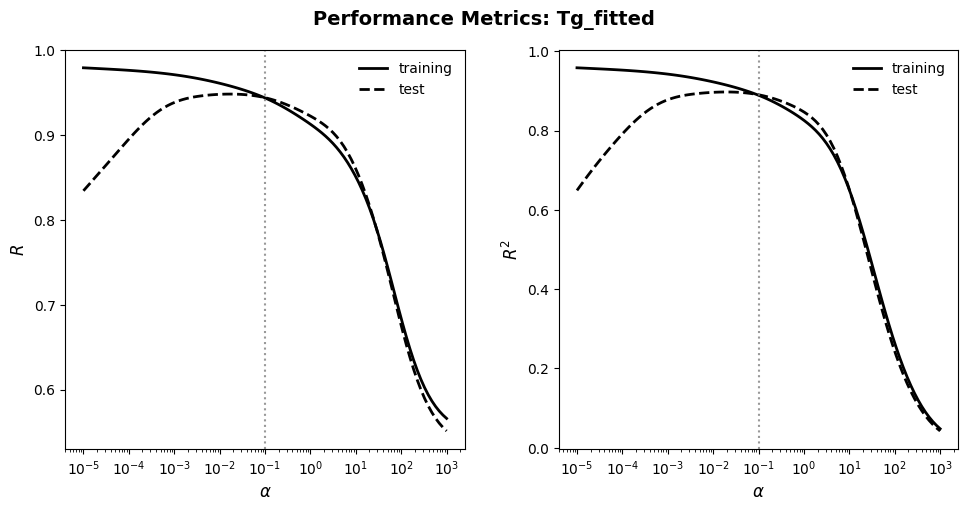

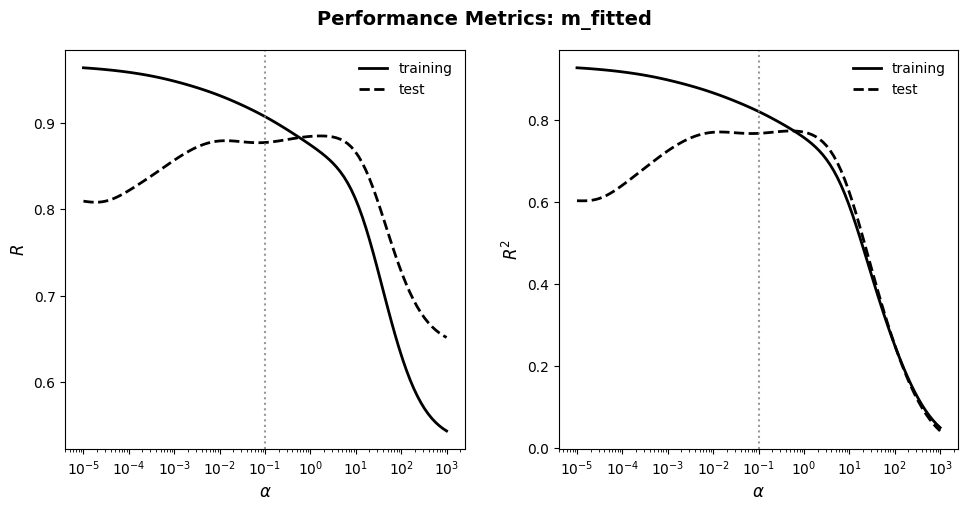

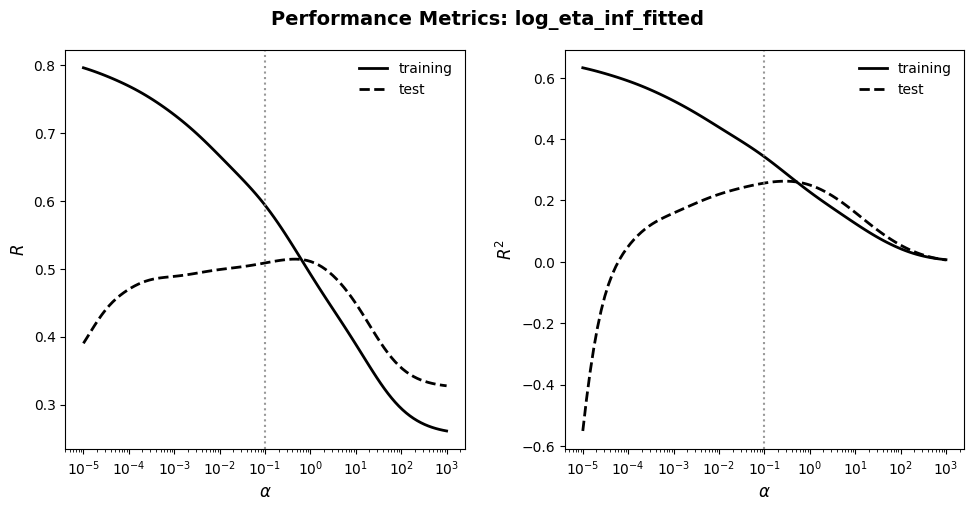

In [15]:
# Model performance analysis as a function of alpha
alphas_spectrum = np.logspace(-5, 3, 100)

performance_results = compute_alpha_performance_metrics(
    X_train_final_standard, 
    y_train_scaled, 
    X_test_final_standard, 
    y_test_scaled, 
    alphas_spectrum
)

performance_plots_path = plots_path / "performance_plots"
performance_plots_path.mkdir(parents=True, exist_ok=True)

for target in performance_results.keys():
    fig = plot_target_performance(
        performance_results[target],
        target_name=target,
        ref_alpha=0.1
    )
    fig.savefig(performance_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-09-23 13:47:09 - Computing robust weight traces across 40 alphas.
[INFO] 2026-09-23 13:47:09 - Averaging over 20 random splits (test_size=0.5).
[INFO] 2026-09-23 13:48:24 - Robust traces computation completed. Packaging results.
[INFO] 2026-09-23 13:48:24 - Rendering robust normalized traces for target: Tg_fitted
[INFO] 2026-09-23 13:48:27 - Rendering robust normalized traces for target: m_fitted
[INFO] 2026-09-23 13:48:29 - Rendering robust normalized traces for target: log_eta_inf_fitted


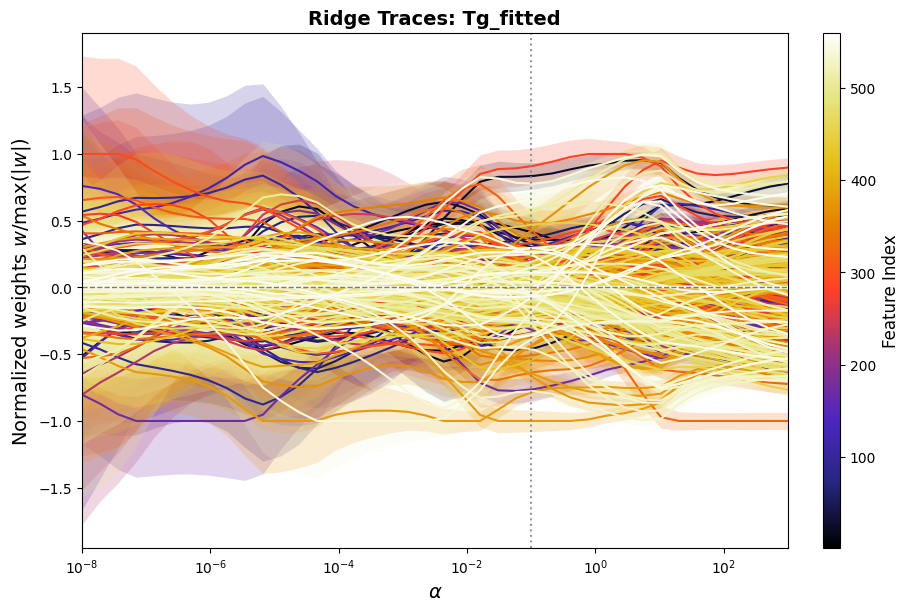

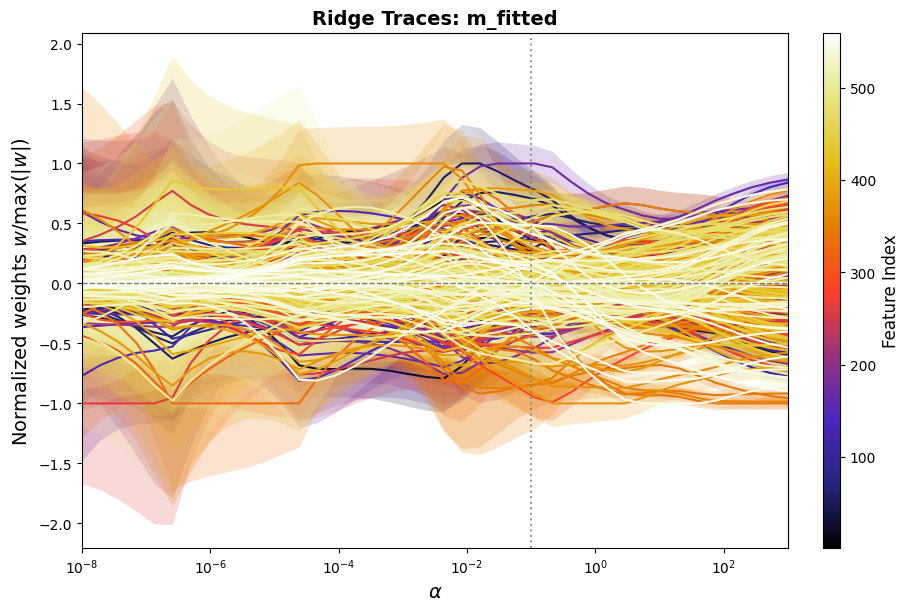

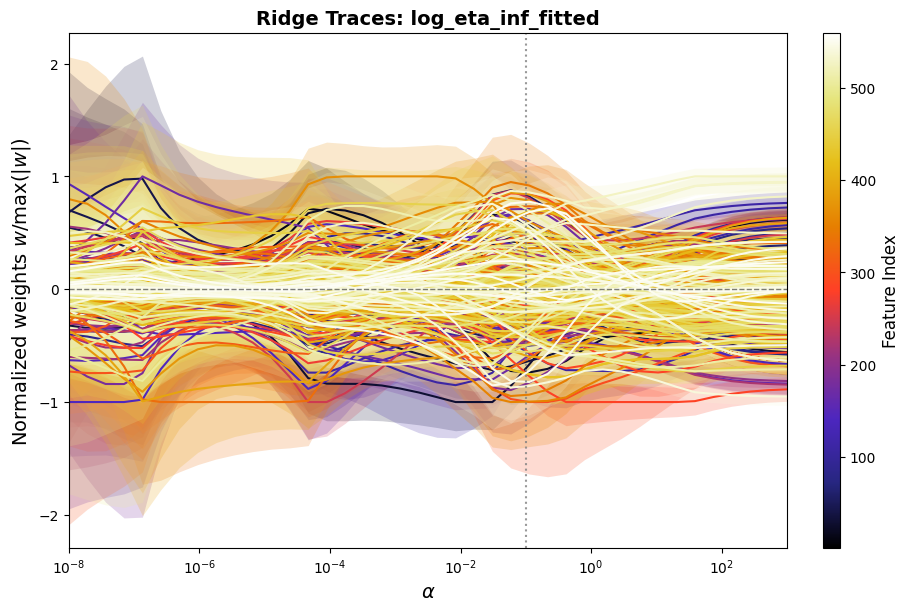

In [16]:
# Features weights analysis in relation to alpha
traces_alphas_spectrum = np.logspace(-8, 3, 40)

robust_traces = compute_weight_traces(
    X=X_train_final_standard,
    y=y_train_scaled,
    alphas=traces_alphas_spectrum,
    n_splits=20,
    test_size=0.5
)

target_names = list(robust_traces.keys())

traces_plots_path = plots_path / "traces_plots"
traces_plots_path.mkdir(parents=True, exist_ok=True)

for target in target_names:
    mean_df = robust_traces[target]["mean_weights"]
    std_df = robust_traces[target]["std_weights"]

    fig = plot_normalized_traces(
        mean_weights=mean_df,
        std_weights=std_df,
        target_name=target
    )
    fig.savefig(traces_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-09-23 13:48:37 - Extracting raw feature importance at alpha=0.1 over 100 splits.
[INFO] 2026-09-23 13:48:46 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,A_Min_ElectronAffinity,356,-0.110292,0.044741,0.110292
1,A_Max_num_oxistates,345,0.105730,0.034312,0.105730
2,W_Min_melting_point,191,-0.091128,0.043726,0.091128
3,W_Sum_GSbandgap,384,0.083434,0.017533,0.083434
4,A_Max_calc_en_sanderson,295,-0.083111,0.064941,0.083111
5,W_Min_ElectronAffinity,351,-0.081080,0.033327,0.081080
6,A_Max_boiling_point,55,0.079908,0.025601,0.079908
7,A_Min_vdw_radius_uff,286,0.079053,0.032175,0.079053
8,W_Sum_vdw_radius,244,0.078823,0.017260,0.078823
9,W_Sum_vdw_radius_uff,284,-0.077686,0.022177,0.077686


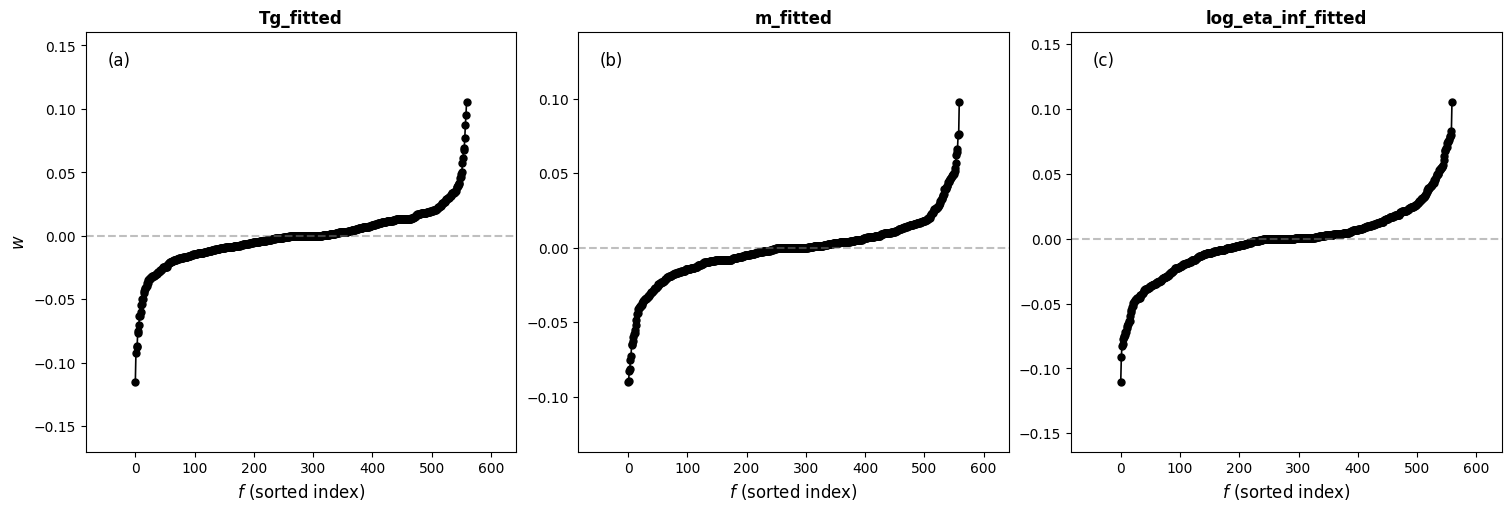

In [17]:
# Feature weights plots (ordered)
importance_data = extract_importance(
    X=X_train_final_standard,
    y=y_train_scaled,
    alpha=0.1,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance_ridge.pdf', bbox_inches='tight')


importance_data['log_eta_inf_fitted'].head(20)
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

[INFO] 2026-09-23 13:48:47 - Tracking evolution of top 5 features (identified at alpha=0.1).
[INFO] 2026-09-23 13:48:56 - Rendering evolution plots, highlighting 3 alphas.


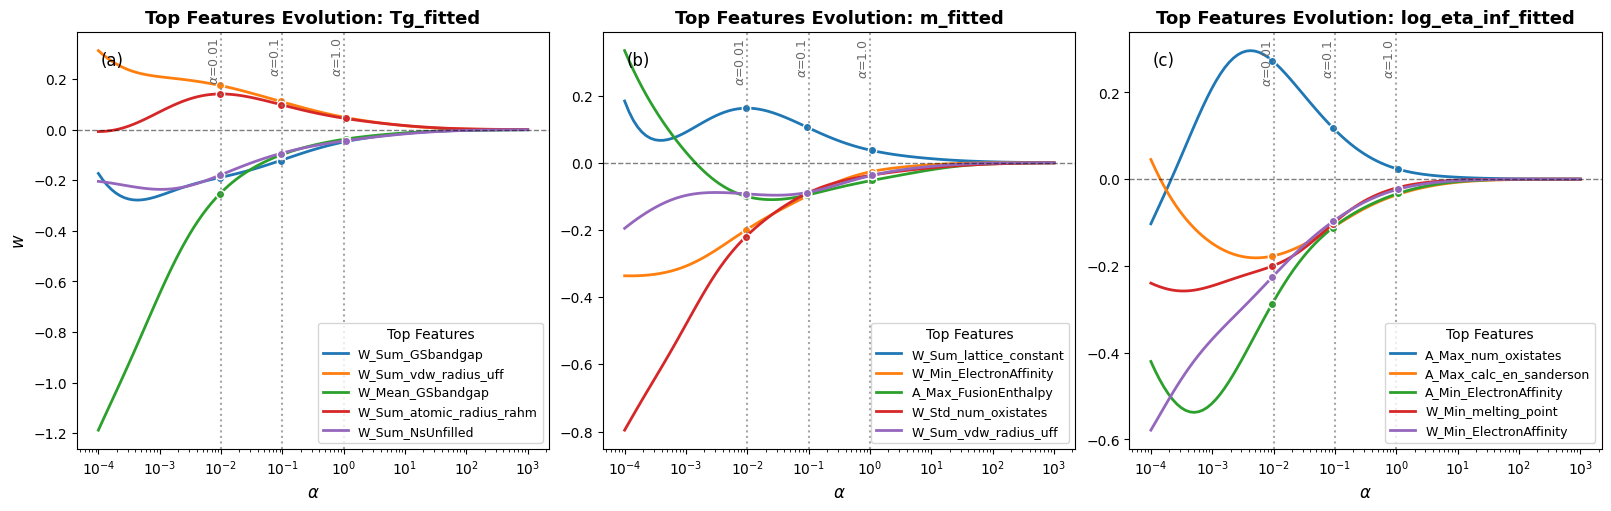

In [18]:
# Top features analisys

alphas_spectrum = np.logspace(-4, 3, 100)

evolution_data = extract_top_features_evolution(
    X=X_train_final_standard,
    y=y_train_scaled,
    alphas=alphas_spectrum,
    ref_alpha=0.1,
    top_n=5
)

selected_alphas = [0.01, 0.1, 1.0]

fig_evolution = plot_top_features_evolution(
    evolution_dict=evolution_data,
    highlight_alphas=selected_alphas
)

fig_evolution.savefig(plots_path / 'top_features_evolution.pdf', bbox_inches='tight')

In [19]:
# Training model

# Instantiate the model with alpha = 0.1
ridge_model = CustomRidgeRegression(alpha=0.1, fit_intercept=True)

# Fit the model on the training data
ridge_model.fit(X_train_final_standard, y_train_scaled)

pickle.dump(ridge_model, open(model_path / "ridge_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-09-23 13:48:59 - Model successfully trained and saved!


In [20]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=ridge_model,
    X_test=X_test_final_standard,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

[INFO] 2026-09-23 13:48:59 - Evaluating model on the unseen Test Set (85 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg
  Pearson : 0.944
  R^2     : 0.890
  RMSE    : 0.312
  MAE     : 0.212
  MedAE   : 0.154
--------------------------------------------------
Target: m
  Pearson : 0.877
  R^2     : 0.769
  RMSE    : 0.495
  MAE     : 0.382
  MedAE   : 0.312
--------------------------------------------------
Target: log_eta_inf
  Pearson : 0.508
  R^2     : 0.257
  RMSE    : 0.801
  MAE     : 0.577
  MedAE   : 0.380
--------------------------------------------------
[INFO] 2026-09-23 13:48:59 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.966
  R^2     : 0.923
  RMSE    : 1.125
  MAE     : 0.711
  MedAE   : 0.424
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
--------------------------------------------------
  Pearson : 

[INFO] 2026-09-23 13:48:59 - Rendering 2D density correlation plot with residual inset.


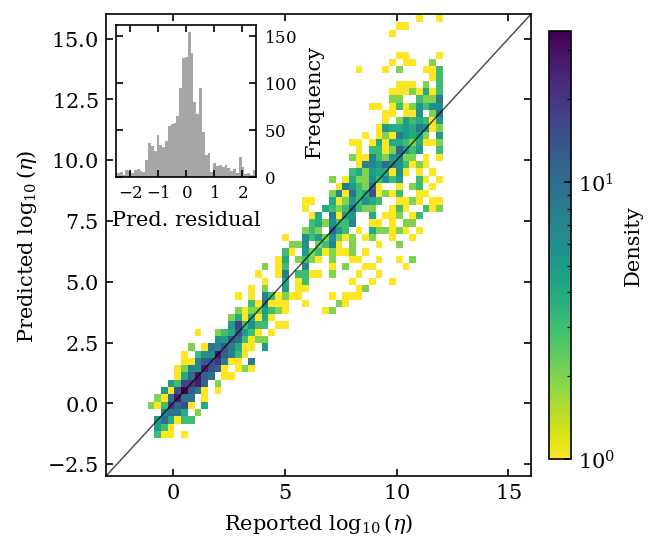

In [21]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-09-23 13:49:01 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,709,1Al₂O₃.50P₂O₅.18SrO.31ZnO,2.010101,4.397180
1,846,25Li₂O.25Na₂O.50P₂O₅,1.321678,4.200604
2,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,3.321194
3,220,74B₂O₃.16BaO.10La₂O₃,1.110106,3.200453
4,265,15Al₂O₃.65B₂O₃.20CaO,0.151111,2.838896
5,273,8Al₂O₃.60B₂O₃.32CaO,0.143369,2.462533
6,659,54B₂O₃.21Na₂O.25SiO₂,0.428105,2.441081
7,806,51Li₂O.49P₂O₅,1.196148,2.293073
8,428,15Na₂O.27PbO.58SiO₂,0.095810,1.823634
9,155,50CaO.50P₂O₅,1.000000,1.779069


[INFO] 2026-09-23 13:49:01 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


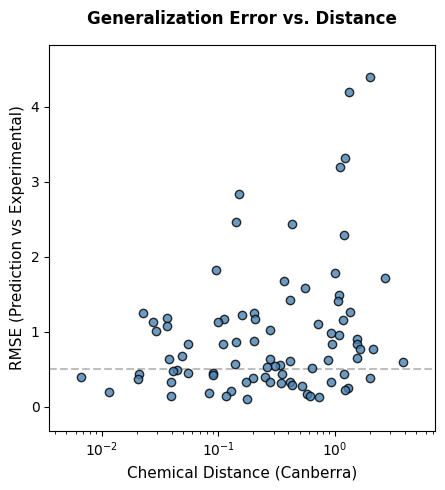

In [22]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = ridge_model.predict(X_test_final_standard)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

In [23]:
test_ids = X_test_final_standard.index
oxide_columns = [col for col in raw_data.columns if col not in ['T', 'log_visc', 'ID']]

composition_test_df = raw_data[raw_data['ID'].isin(test_ids)].copy()
composition_test_df = composition_test_df.drop_duplicates(subset=['ID'])
composition_test_df = composition_test_df.set_index('ID')
composition_test_df = composition_test_df[oxide_columns]
composition_test_df = composition_test_df.fillna(0)

composition_test_df

,Al2O3,As2O3,B2O3,BaO,BeO,Bi2O3,CaO,CdO,CoO,Cs2O,...,SiO2,SrO,Ta2O5,TeO2,TiO2,Tl2O,WO3,Y2O3,ZnO,ZrO2
ID,,,,,,,,,,,,,,,,,,,,,
5,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
8,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
14,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
17,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
18,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,0.00,0.0,0.00,0.0,0.0,0.0,0.06,0.0,0.0,0.0,...,0.73,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
819,0.00,0.0,0.00,0.0,0.0,0.0,0.06,0.0,0.0,0.0,...,0.71,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0
835,0.01,0.0,0.24,0.0,0.0,0.0,0.03,0.0,0.0,0.0,...,0.68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0


[INFO] 2026-09-23 13:49:02 - Computing global viscosity residuals across chemical compounds.
[INFO] 2026-09-23 13:49:02 - Rendering global viscosity compound residual plot.


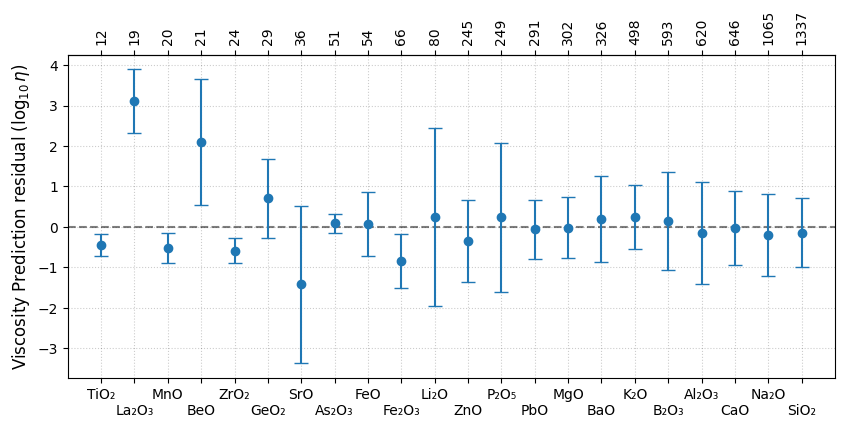

In [24]:
# composition_test_df è il DataFrame con le moli (Na2O, SiO2...) per i vetri nel Test Set
viscosity_residuals_df = compute_global_viscosity_residuals(
    viscosity_df=raw_data,               # Il dataset sperimentale (con le colonne ID, T, log_visc)
    predictions_df=predictions_df,       # I tre parametri predetti
    composition_df=composition_test_df   # Le frazioni molari degli ossidi
)

residuals_plots_path = plots_path / "residuals_analysis"
residuals_plots_path.mkdir(parents=True, exist_ok=True)

fig_visc_res = plot_viscosity_compound_residuals(viscosity_residuals_df)
fig_visc_res.savefig(residuals_plots_path / "Global_Viscosity_Error_Compound.pdf", bbox_inches='tight')

[INFO] 2026-09-23 13:49:02 - Training ensemble of 100 bootstrap models...
[INFO] 2026-09-23 13:49:13 - Rendering bootstrap prediction grids for 85 glasses.


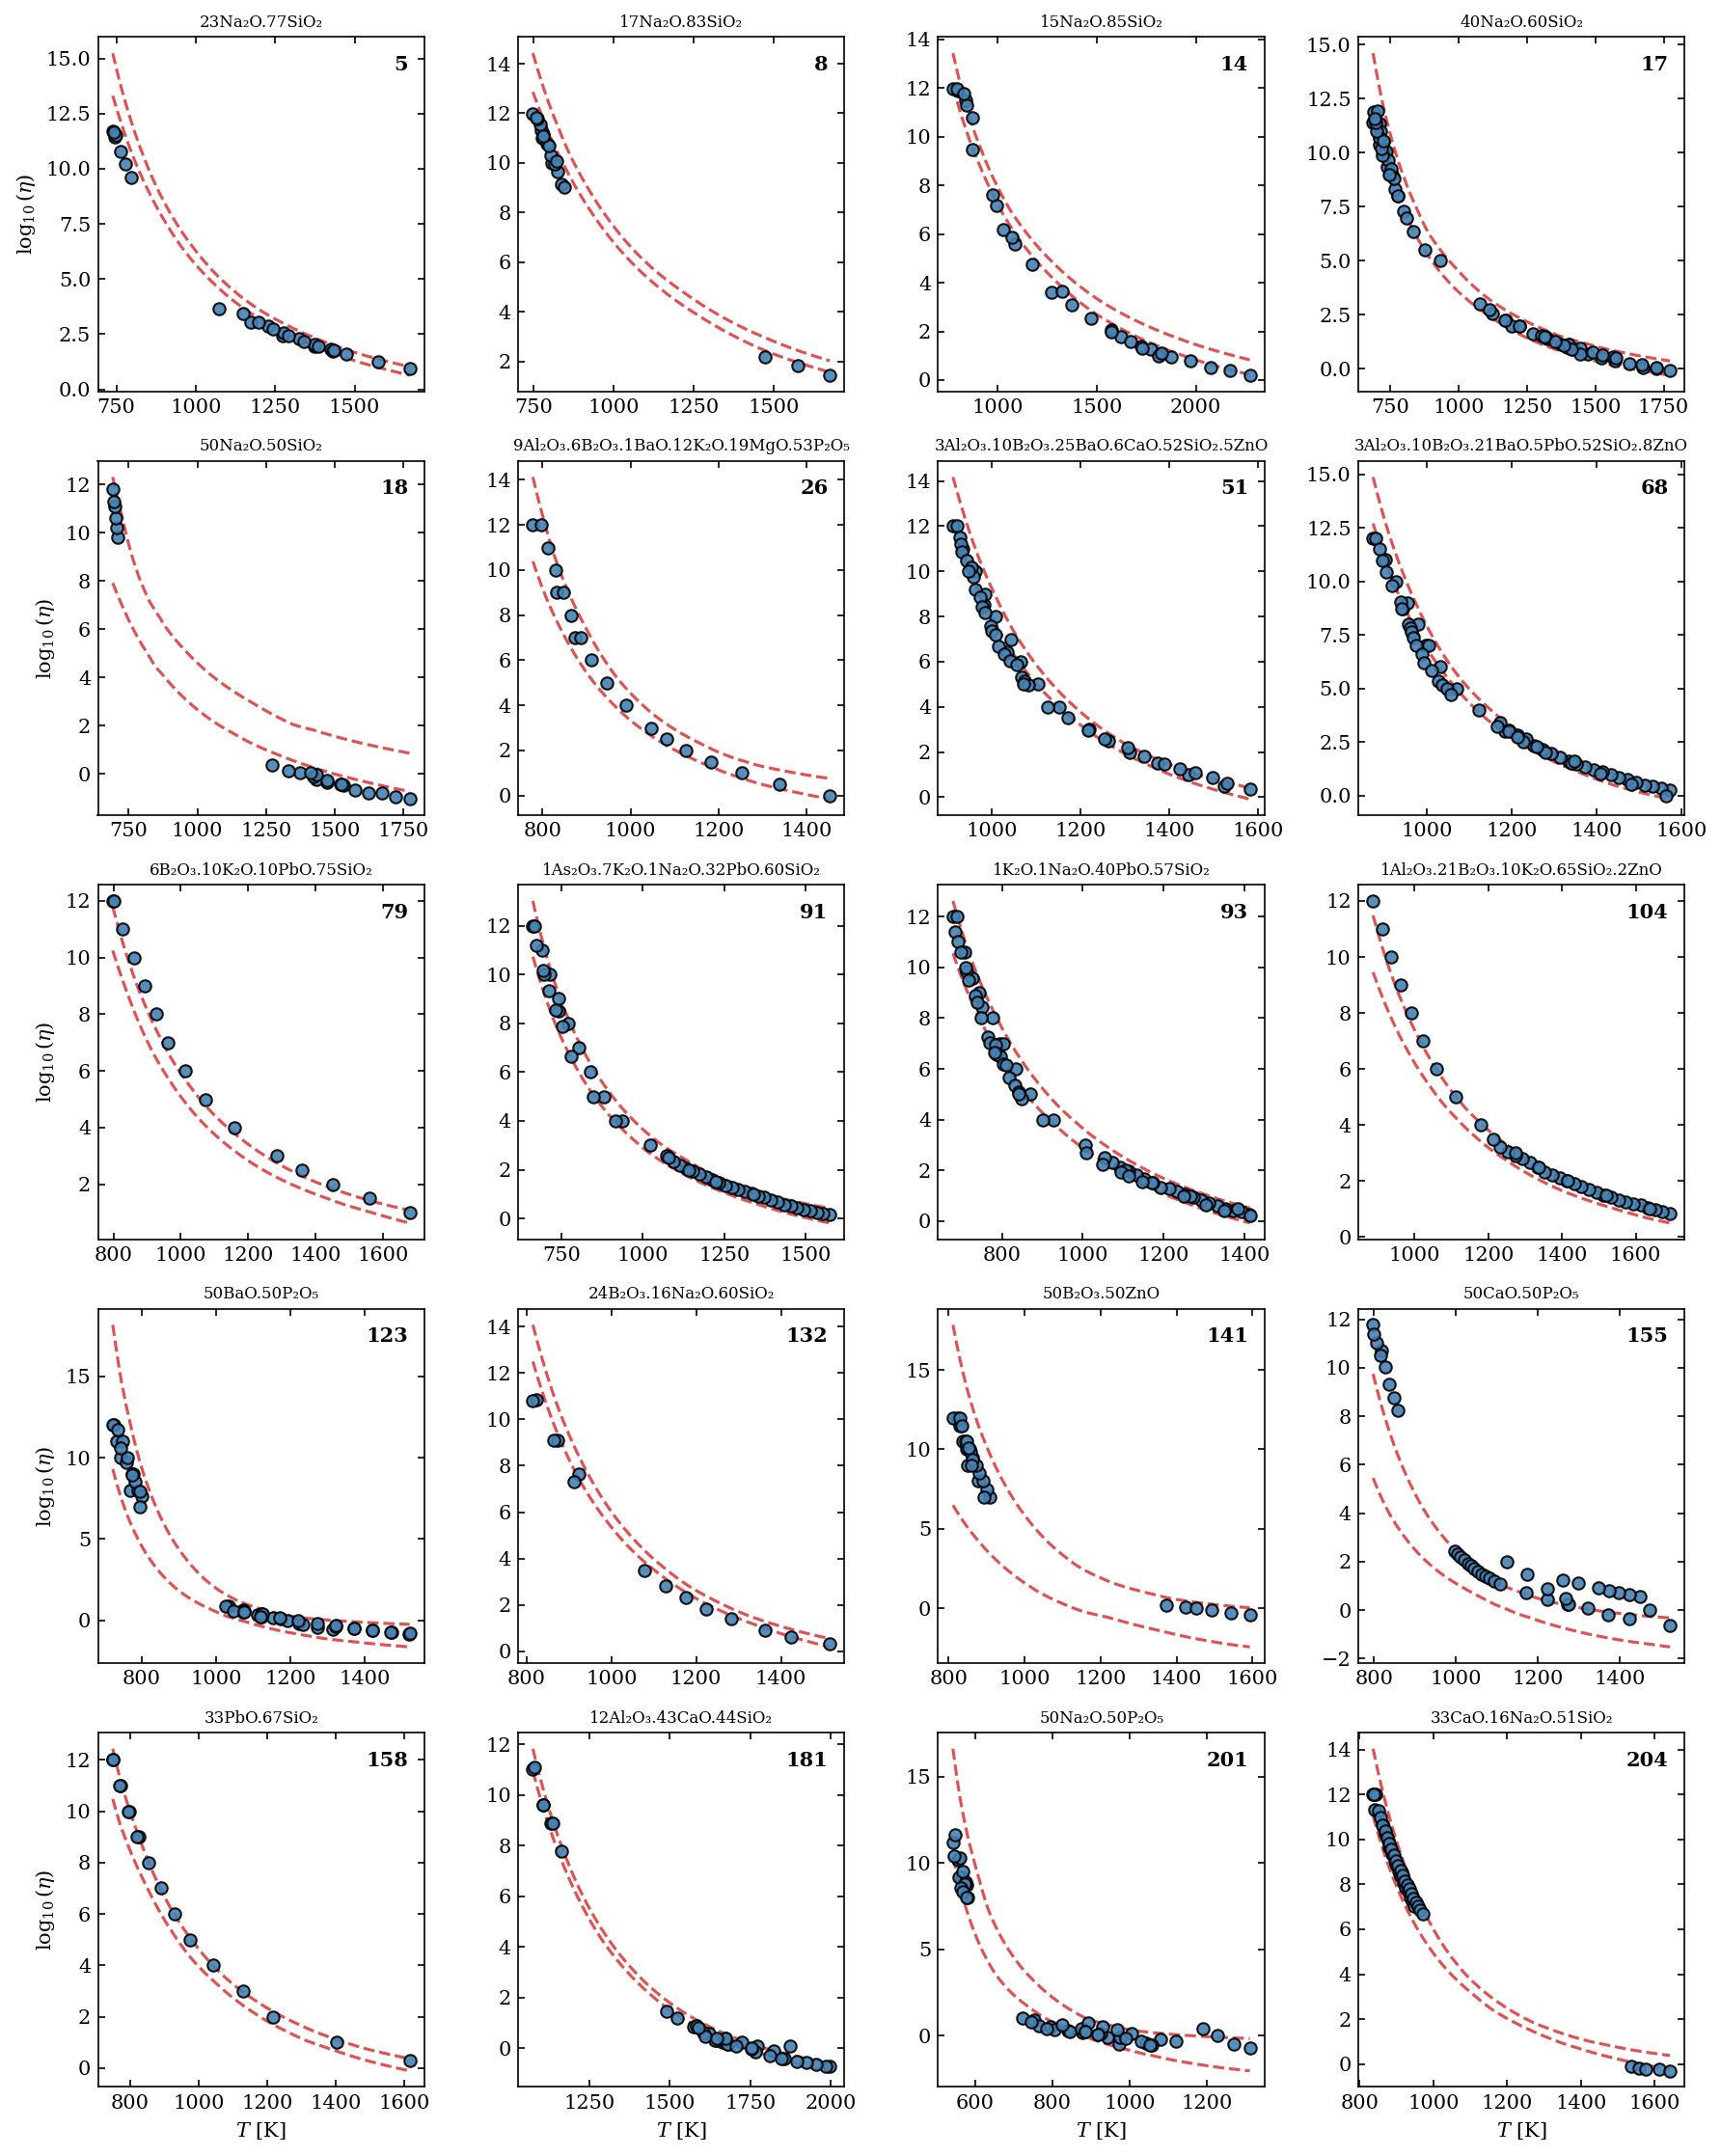

In [25]:
# Plotting test liquids viscosities with uncertainty bars

base_ridge = CustomRidgeRegression(alpha=0.1, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=base_ridge,
    X_train=X_train_final_standard,
    y_train=y_train_scaled,
    X_test=X_test_final_standard,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)